# 5. Decision Tree and Random Forest
## Importing Dependencies

In [1]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import sys
from pathlib import Path

# Add the project root (ml_laboratory) to Python's search path
sys.path.append(str(Path().resolve().parent))
from utils import (
    eda_tabular
)
print("Imported")

Imported successfully
Imported


## EDA Analysis

In [2]:
df = pd.read_csv("../datasets/breastCancer/wdbc.data",header=None)
features = [
    "radius", "texture", "perimeter", 
    "area", "smoothness",
    "compactness", "concavity", "concave_points", "symmetry", "fractal_dimension"
]

column_names = ["id", "diagnosis"]
for suffix in ["_mean", "_se", "_worst"]:
    column_names.extend([f"{feat}{suffix}" for feat in features])

df.columns = column_names
display(df.head())


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Shape: (569, 32)

Column types:
 id                           int64
diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave_points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave_points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst     

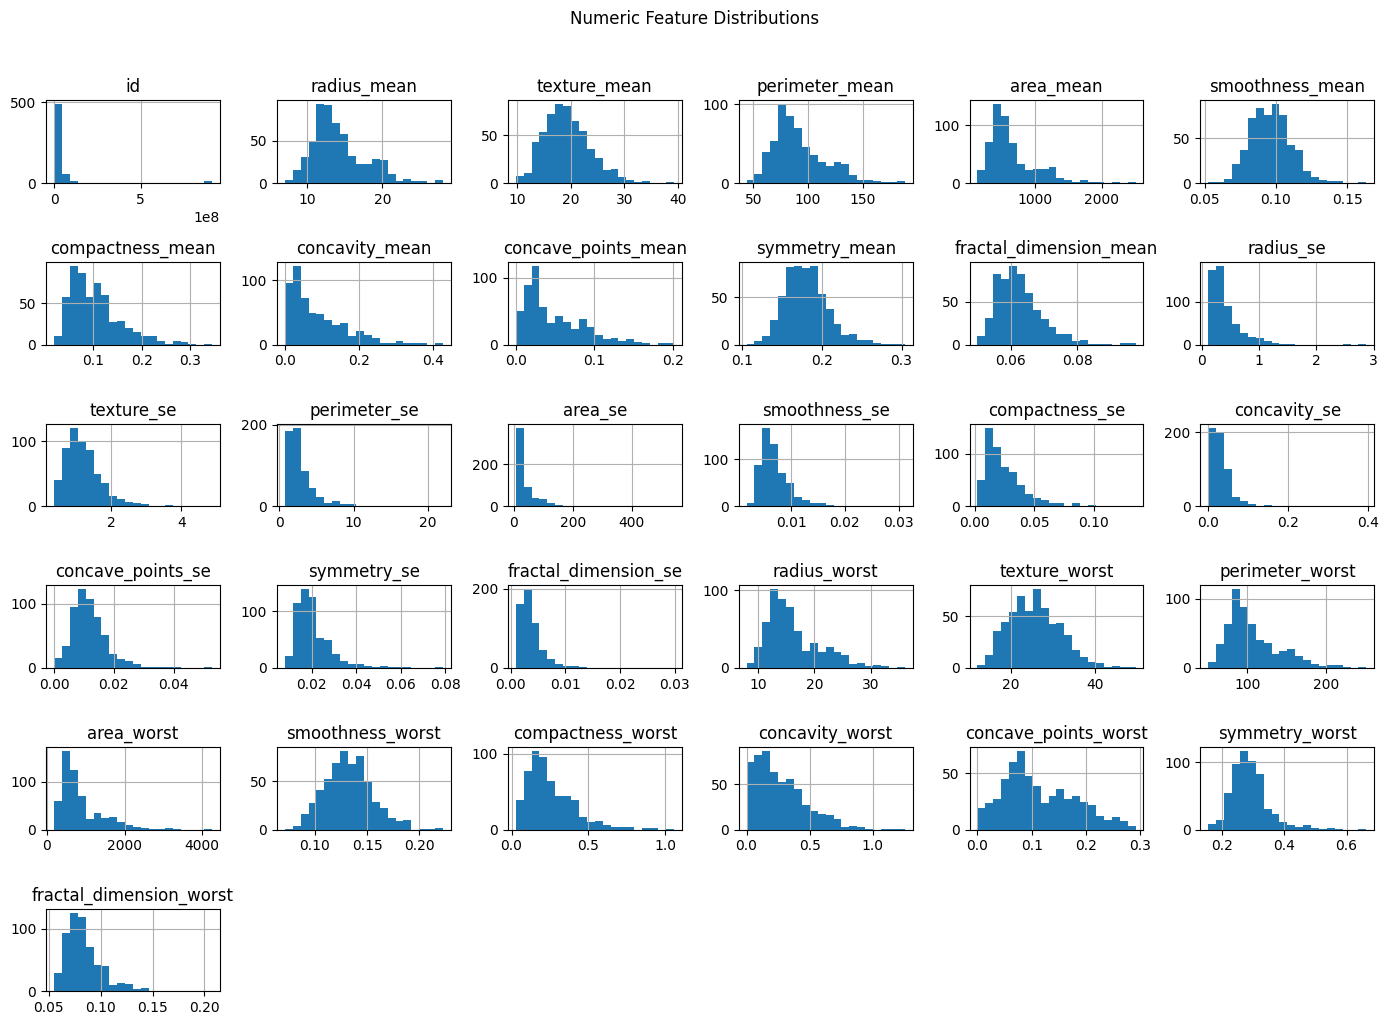

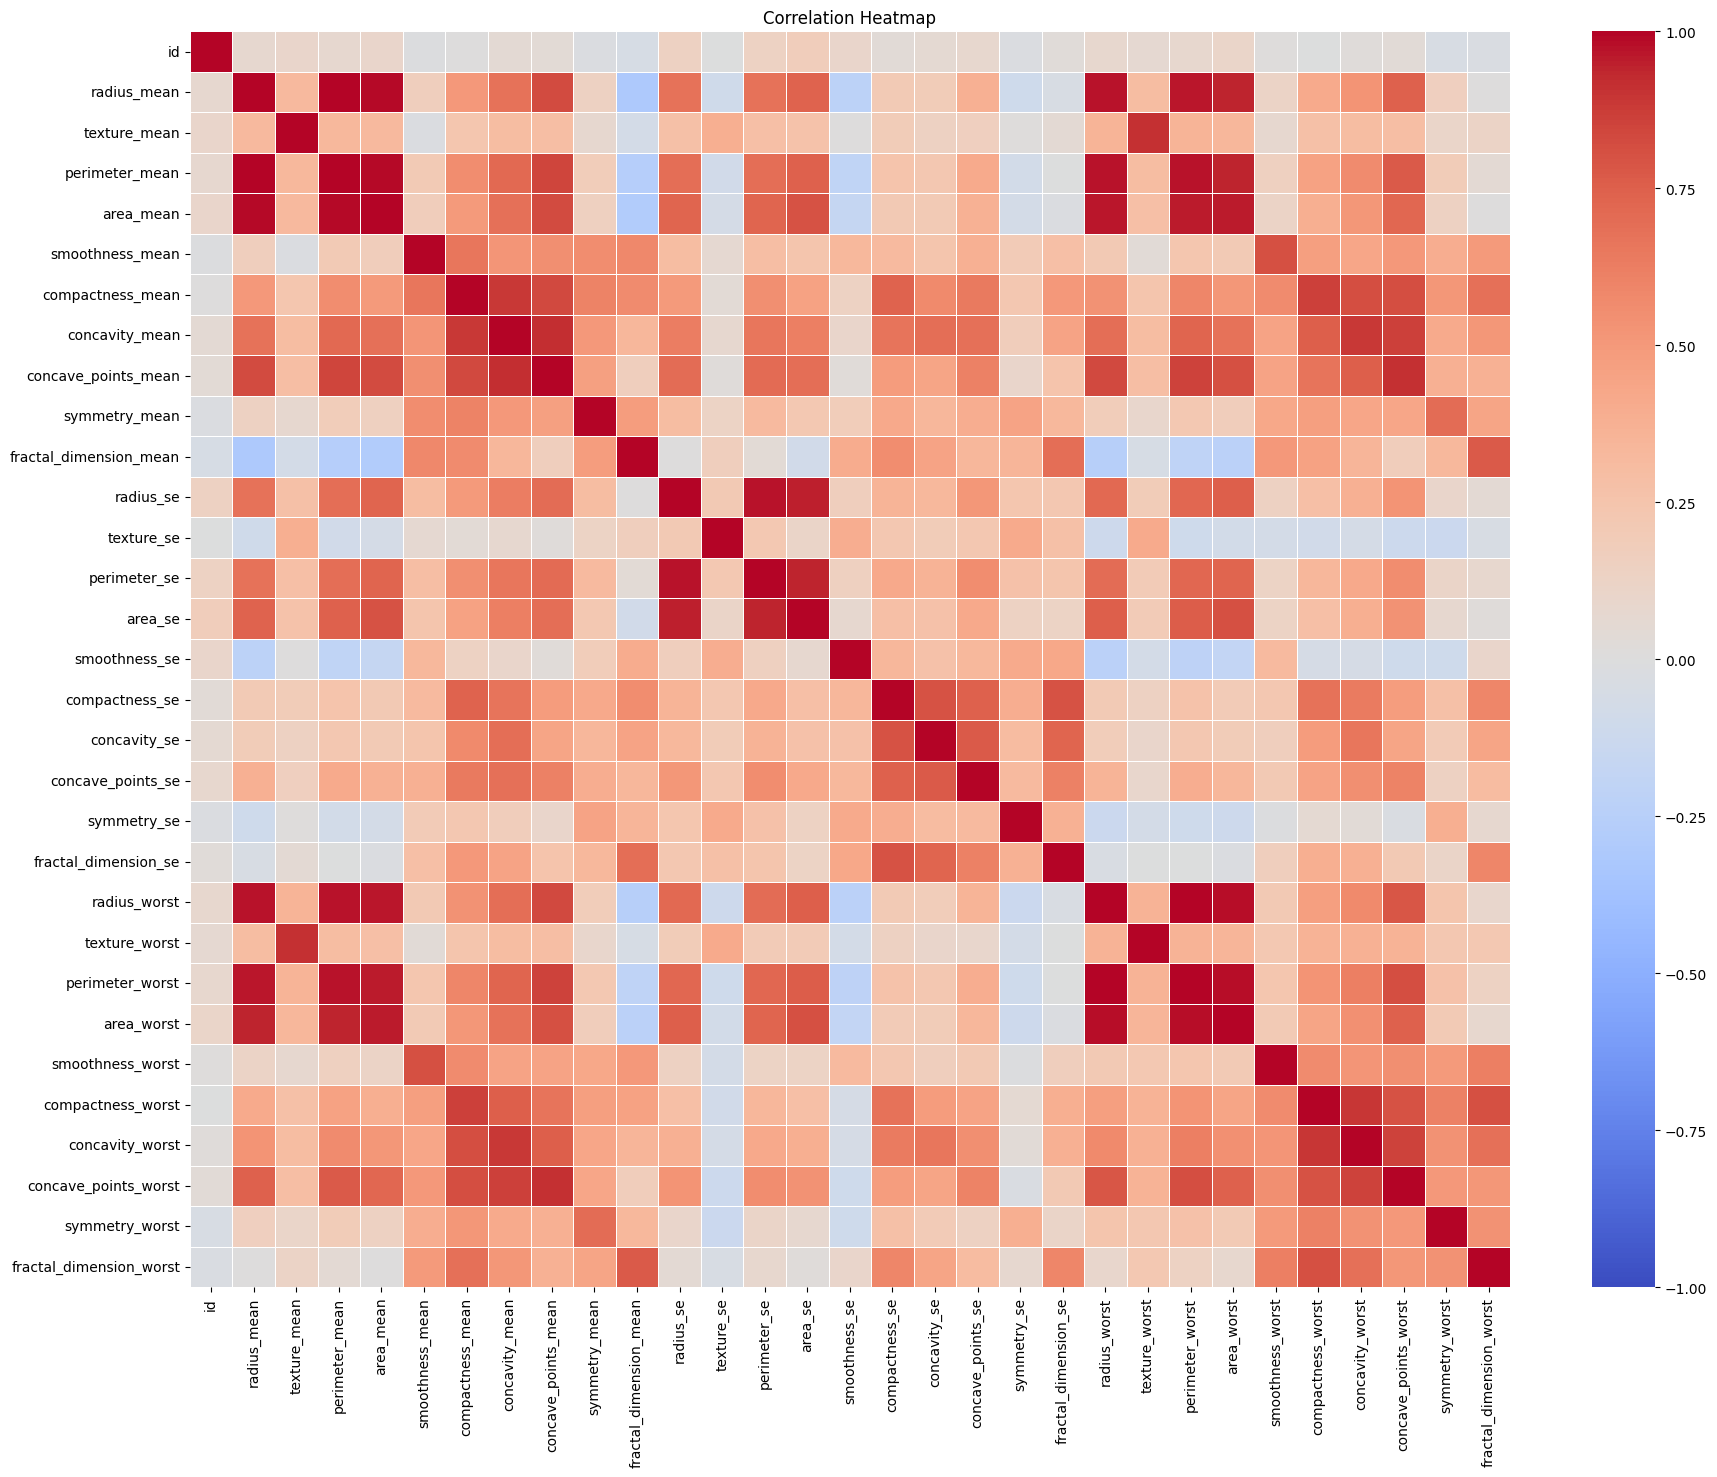

(Index(['id', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
        'smoothness_mean', 'compactness_mean', 'concavity_mean',
        'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
        'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
        'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se',
        'fractal_dimension_se', 'radius_worst', 'texture_worst',
        'perimeter_worst', 'area_worst', 'smoothness_worst',
        'compactness_worst', 'concavity_worst', 'concave_points_worst',
        'symmetry_worst', 'fractal_dimension_worst'],
       dtype='str'),
 Index(['diagnosis'], dtype='str'))

In [12]:
eda_tabular(df)

In [4]:
def class_dist_plot(df, target):
    a=df[target].value_counts()
    print(a)
    a.plot(kind="bar")
    plt.title("Class Distribution")
    plt.ylabel("Count")
    plt.show()

diagnosis
B    357
M    212
Name: count, dtype: int64


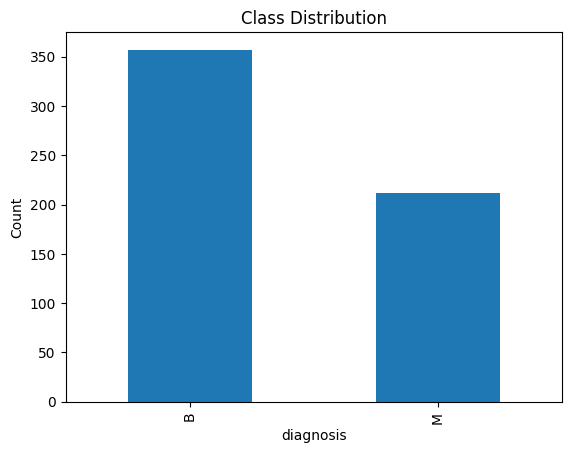

In [5]:
class_dist_plot(df,"diagnosis")


## Train Test Split

In [3]:
from sklearn.model_selection import train_test_split
X = df.drop(['diagnosis'], axis=1)
y = df['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

print(f"X Train shape - {X_train.shape} & X Test shape - {X_test.shape}")
print(f"y Train shape - {y_train.shape} & y Test shape - {y_test.shape}")

X Train shape - (455, 31) & X Test shape - (114, 31)
y Train shape - (455,) & y Test shape - (114,)


In [60]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred =model.predict(X_test)
# display(model)

print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"\nClassification Report:\n {classification_report(y_test, y_pred)}")



Test Accuracy: 0.947

Classification Report:
               precision    recall  f1-score   support

           B       0.96      0.96      0.96        71
           M       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [61]:
from sklearn.model_selection import GridSearchCV
base_tree = DecisionTreeClassifier(random_state=42)

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=base_tree,
    param_grid=param_grid,
    cv=5,                 
    scoring='accuracy',   
    n_jobs=-1             
)

grid_search.fit(X_train, y_train)

# Display the best parameter combination and best cross-validation score
print("Best Hyperparameters:", grid_search.best_params_)
print("Best 5-Fold CV Score:", round(grid_search.best_score_, 4))

# 4. Predict and Evaluate using the Best Model on the Test Set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best 5-Fold CV Score: 0.9473

Test Accuracy: 0.956

Classification Report:
               precision    recall  f1-score   support

           B       0.95      0.99      0.97        71
           M       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
rf_base = RandomForestClassifier(random_state=42)
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf_grid_search = GridSearchCV(
    estimator = rf_base,
    param_grid = rf_param_grid,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1
)
rf_grid_search.fit(X_train, y_train)

best_rf_model = rf_grid_search.best_estimator_

y_pred_dt = best_model.predict(X_test)
y_pred_rf = best_rf_model.predict(X_test)

print("Best Decision Tree Params:", grid_search.best_params_)
print("Best Random Forest Params:", rf_grid_search.best_params_)

# ==========================================
# Step 10: Model Comparison
# ==========================================

# Calculate metrics for both models (Assumes multi-class/binary classification)
metrics_data = {
    "Model": ["Decision Tree", "Random Forest"],
    "Best CV Score": [grid_search.best_score_, rf_grid_search.best_score_],
    "Test Accuracy": [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf)],
    "Precision (Weighted)": [precision_score(y_test, y_pred_dt, average='weighted'), precision_score(y_test, y_pred_rf, average='weighted')],
    "Recall (Weighted)": [recall_score(y_test, y_pred_dt, average='weighted'), recall_score(y_test, y_pred_rf, average='weighted')],
    "F1-Score (Weighted)": [f1_score(y_test, y_pred_dt, average='weighted'), f1_score(y_test, y_pred_rf, average='weighted')]
}

# Display side-by-side comparison table
comparison_df = pd.DataFrame(metrics_data)
display(comparison_df)

Best Decision Tree Params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Random Forest Params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


,Model,Best CV Score,Test Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted)
0,Decision Tree,0.947253,0.956140,0.956905,0.956140,0.955801
1,Random Forest,0.960440,0.964912,0.965205,0.964912,0.964738
